In [1]:
# # 🚀 Customer Churn Prediction & Business Analysis

# ## Module 6 – Final Data Science Project

# This project focuses on analyzing customer data, identifying factors
# related to customer churn, and building a Machine Learning model
# to predict whether a customer is likely to churn.

# ### Objectives

# - Understand the customer dataset
# - Clean and preprocess the data
# - Perform Exploratory Data Analysis (EDA)
# - Visualize important patterns
# - Identify factors associated with churn
# - Build a Machine Learning classification model
# - Evaluate model performance
# - Generate business insights

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

In [4]:
df = pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [5]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [6]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,No,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [8]:
print("Number of Rows: ", df.shape[0])
print("Number of Columns: "), df.shape[1]

Number of Rows:  7043
Number of Columns: 


(None, 21)

In [9]:
print("Columns: ")
print(df.columns.tolist())

Columns: 
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [11]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [12]:
print("Missing Values: ")
print(df.isnull().sum())

Missing Values: 
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [13]:
print("Duplicated Rows: ", df.duplicated().sum())

Duplicated Rows:  0


In [14]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

print(df.isnull().sum())

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [15]:
df["TotalCharges"] = df["TotalCharges"].fillna(
    df["TotalCharges"].median()
)

print("Missing values after cleaning:")
print(df.isnull().sum().sum())

Missing values after cleaning:
0


In [16]:
df = df.drop("customerID", axis=1)

print("Customer ID removed.")

Customer ID removed.


In [17]:
print(df["Churn"].value_counts())

Churn
No     5174
Yes    1869
Name: count, dtype: int64


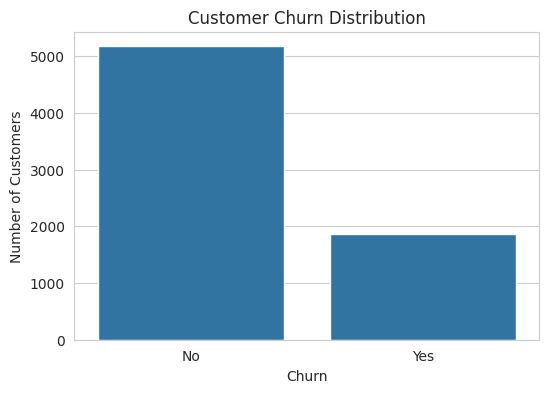

In [18]:
plt.figure(figsize=(6, 4))

sns.countplot(x="Churn", data=df)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

In [19]:
gender_churn = pd.crosstab(
    df["gender"],
    df["Churn"]
)

print(gender_churn)

Churn     No  Yes
gender           
Female  2549  939
Male    2625  930


In [20]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"]
)

print(contract_churn)

Churn             No   Yes
Contract                  
Month-to-month  2220  1655
One year        1307   166
Two year        1647    48


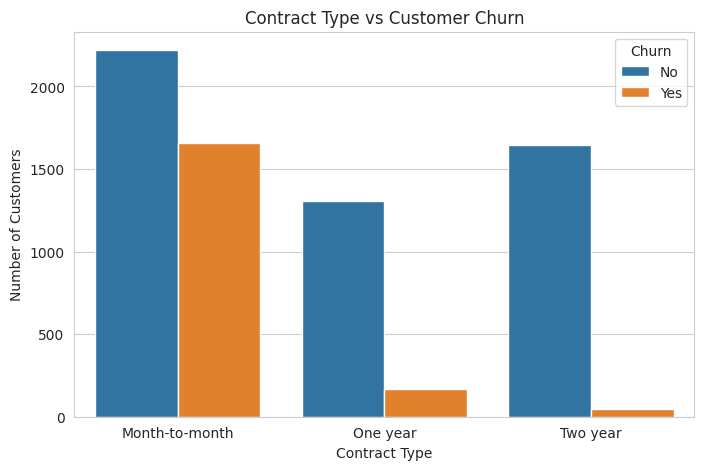

In [21]:
plt.figure(figsize=(8, 5))

sns.countplot(
    x="Contract",
    hue="Churn",
    data=df
)

plt.title("Contract Type vs Customer Churn")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.show()

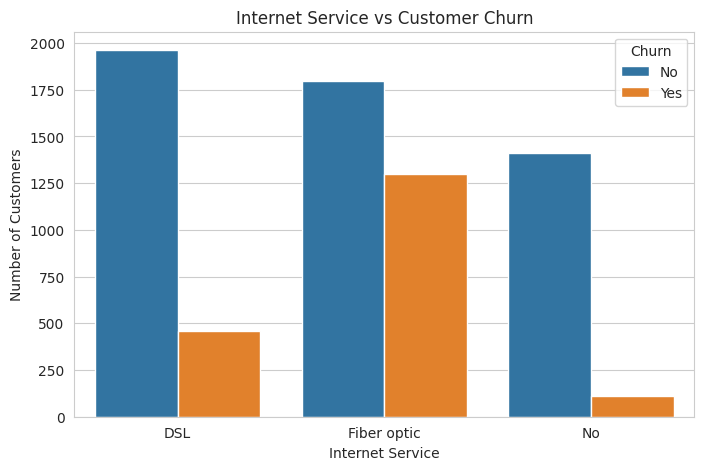

In [22]:
plt.figure(figsize=(8, 5))

sns.countplot(
    x="InternetService",
    hue="Churn",
    data=df
)

plt.title("Internet Service vs Customer Churn")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")

plt.show()

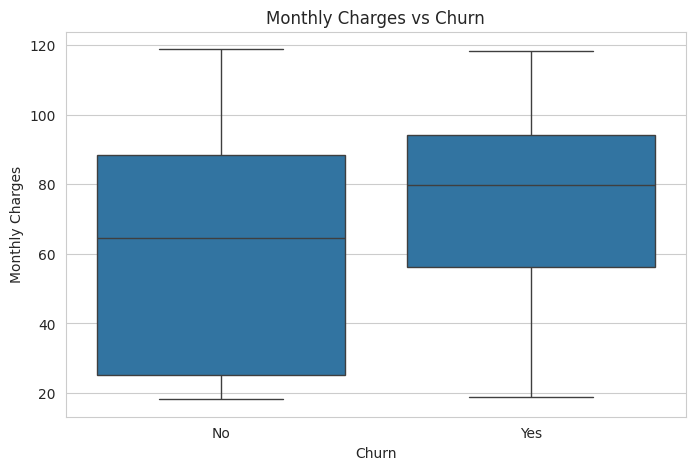

In [23]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="Churn",
    y="MonthlyCharges",
    data=df
)

plt.title("Monthly Charges vs Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

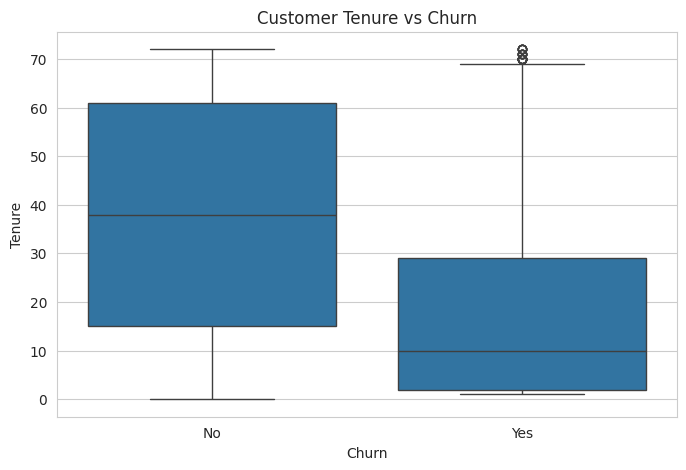

In [24]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="Churn",
    y="tenure",
    data=df
)

plt.title("Customer Tenure vs Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure")

plt.show()

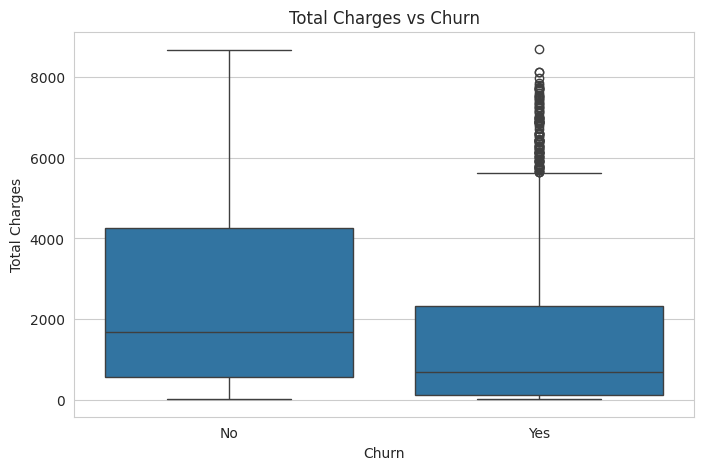

In [25]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="Churn",
    y="TotalCharges",
    data=df
)

plt.title("Total Charges vs Churn")
plt.xlabel("Churn")
plt.ylabel("Total Charges")

plt.show()

In [26]:
numerical_df = df.select_dtypes(include=np.number)

correlation = numerical_df.corr()

print(correlation)

                SeniorCitizen    tenure  MonthlyCharges  TotalCharges
SeniorCitizen        1.000000  0.016567        0.220173      0.102652
tenure               0.016567  1.000000        0.247900      0.825464
MonthlyCharges       0.220173  0.247900        1.000000      0.650864
TotalCharges         0.102652  0.825464        0.650864      1.000000


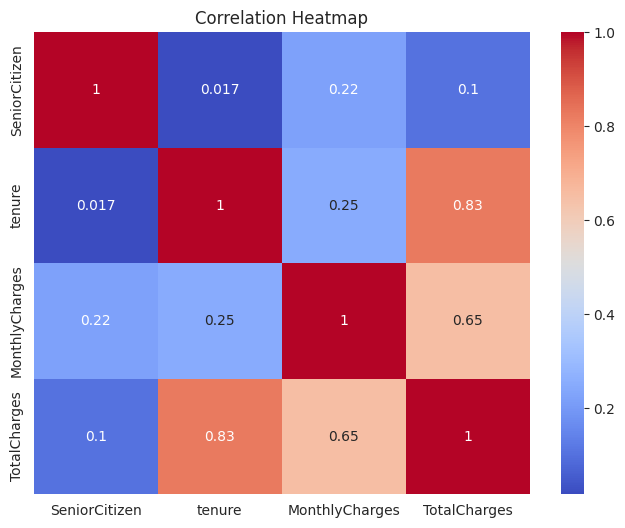

In [27]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [28]:
df_ml = df.copy()

label_encoder = LabelEncoder()

for column in df_ml.select_dtypes(include="object").columns:
    df_ml[column] = label_encoder.fit_transform(df_ml[column])

df_ml.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


In [29]:
X = df_ml.drop("Churn", axis=1)
y = df_ml["Churn"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (7043, 19)
Target: (7043,)


In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (5634, 19)
Testing Data: (1409, 19)


In [31]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [32]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [33]:
y_pred = model.predict(X_test)

print("Predictions generated successfully!")

Predictions generated successfully!


In [34]:
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100)


Model Accuracy: 0.7991483321504613
Accuracy Percentage: 79.91483321504613


In [35]:
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.89      0.87      1035
           1       0.64      0.55      0.59       374

    accuracy                           0.80      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409



In [36]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[921 114]
 [169 205]]


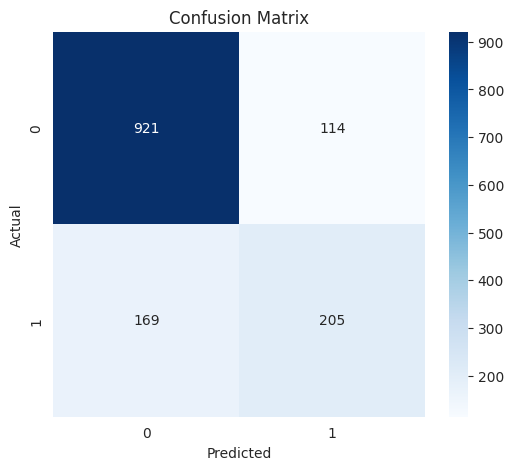

In [37]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [38]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

feature_importance["Absolute_Importance"] = (
    feature_importance["Coefficient"].abs()
)

feature_importance = feature_importance.sort_values(
    "Absolute_Importance",
    ascending=False
)

print(feature_importance)

             Feature  Coefficient  Absolute_Importance
4             tenure    -1.212465             1.212465
17    MonthlyCharges     0.737153             0.737153
14          Contract    -0.605002             0.605002
18      TotalCharges     0.477248             0.477248
5       PhoneService    -0.291312             0.291312
8     OnlineSecurity    -0.246553             0.246553
11       TechSupport    -0.228527             0.228527
15  PaperlessBilling     0.194977             0.194977
7    InternetService     0.177280             0.177280
9       OnlineBackup    -0.131782             0.131782
3         Dependents    -0.109569             0.109569
16     PaymentMethod     0.095038             0.095038
6      MultipleLines     0.086641             0.086641
10  DeviceProtection    -0.075426             0.075426
1      SeniorCitizen     0.062657             0.062657
2            Partner     0.019151             0.019151
0             gender     0.007937             0.007937
12       S

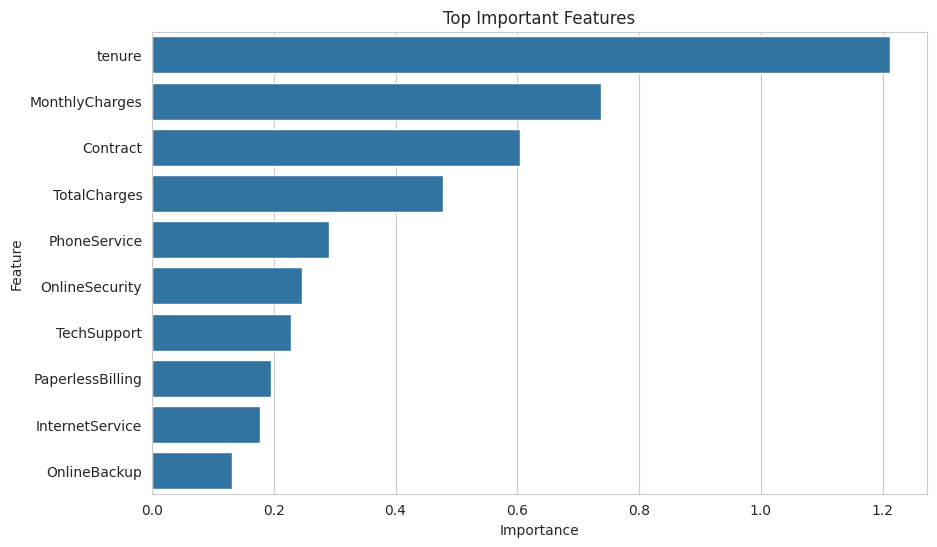

In [39]:
plt.figure(figsize=(10, 6))

top_features = feature_importance.head(10)

sns.barplot(
    x="Absolute_Importance",
    y="Feature",
    data=top_features
)

plt.title("Top Important Features")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [40]:
sample_customer = X_test[0].reshape(1, -1)

prediction = model.predict(sample_customer)

if prediction[0] == 1:
    print("Prediction: Customer is likely to churn.")
else:
    print("Prediction: Customer is likely to stay.")

Prediction: Customer is likely to stay.


In [42]:
print("= FINAL RESULTS =")

print("Dataset Records:", len(df))
print("Number of Features:", X.shape[1])
print("Model: Logistic Regression")
print("Accuracy:", round(accuracy * 100, 2), "%")

= FINAL RESULTS =
Dataset Records: 7043
Number of Features: 19
Model: Logistic Regression
Accuracy: 79.91 %


In [43]:
churn_rate = (df["Churn"] == "Yes").mean() * 100

print("========== BUSINESS INSIGHTS ==========")

print("Customer Churn Rate:",
      round(churn_rate, 2), "%")

print(
    "Most common contract type:",
    df["Contract"].mode()[0]
)

print(
    "Most common internet service:",
    df["InternetService"].mode()[0]
)

print(
    "Average monthly charge:",
    round(df["MonthlyCharges"].mean(), 2)
)

print(
    "Average customer tenure:",
    round(df["tenure"].mean(), 2)
)

========== BUSINESS INSIGHTS ==========
Customer Churn Rate: 26.54 %
Most common contract type: Month-to-month
Most common internet service: Fiber optic
Average monthly charge: 64.76
Average customer tenure: 32.37


In [44]:
# # 🔍 Key Insights

# ### 1. Customer Churn
# The dataset was analyzed to understand the proportion of customers
# who have churned and those who have remained with the company.

# ### 2. Contract Type
# Customer churn was compared across different contract types to
# identify differences in customer retention.

# ### 3. Internet Service
# Internet service types were analyzed to understand their relationship
# with customer churn.

# ### 4. Monthly Charges
# Monthly charges were compared between customers who churned and
# customers who stayed.

# ### 5. Customer Tenure
# Customer tenure was analyzed to understand customer retention behavior.

# ### 6. Machine Learning
# A Logistic Regression classification model was developed to predict
# customer churn.

# ### 7. Model Evaluation
# The model was evaluated using accuracy, classification report,
# and confusion matrix.

# ### 8. Business Value
# The analysis can help businesses identify customer groups that may
# require better retention strategies.

In [46]:
# #  Conclusion

# This project demonstrated an end-to-end Data Science workflow for
# Customer Churn Prediction.

# The customer dataset was loaded, explored, cleaned, and analyzed
# using Python. Pandas and NumPy were used for data processing, while
# Matplotlib and Seaborn were used for data visualization.

# Exploratory Data Analysis was performed to understand customer
# behavior and factors related to churn.

# A Logistic Regression Machine Learning model was then trained to
# predict customer churn. The model was evaluated using accuracy,
# classification report, and confusion matrix.

# ## Skills Demonstrated

# - Python
# - Pandas
# - NumPy
# - Data Cleaning
# - Exploratory Data Analysis
# - Data Visualization
# - Matplotlib
# - Seaborn
# - Feature Preprocessing
# - Machine Learning
# - Logistic Regression
# - Model Evaluation
# - Business Insights